# 05 · Regression

[← Course home](../README.md)

Linear regression is the "hello world" of machine learning — and, done carefully, it already contains most
of the big ideas: loss functions, optimisation, evaluation, regularisation and the bias–variance trade-off.

**What you will learn**

- Solve least squares **from scratch** with the normal equations (`solve`, `lstsq`, `pinv`) and understand
  why conditioning matters
- Implement **batch, stochastic and mini-batch gradient descent**, and see what the learning rate does
  (including divergence)
- Compute and interpret **MSE, RMSE, MAE and R²**, and read **residual plots**
- Regularise with **Ridge** (closed form from scratch) and **Lasso**; read coefficient paths; see why scaling
  matters
- Diagnose under- and over-fitting with **validation curves** and **learning curves**
- Measure the **bias–variance decomposition** empirically by simulation

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.datasets import load_diabetes
from sklearn.linear_model import (ElasticNet, Lasso, LassoCV, LinearRegression, Ridge, RidgeCV,
                                  SGDRegressor)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, learning_curve, train_test_split, validation_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, PolynomialFeatures, StandardScaler

from mlaz import PALETTE, load_mpg, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.precision", 4)

## 1 · The model and the loss

With $n$ examples and $d$ features, stack the inputs into a design matrix $X\in\mathbb R^{n\times(d+1)}$
whose first column is all ones (the intercept). Linear regression predicts

$$\hat{\mathbf y} = X\boldsymbol\theta$$

and chooses $\boldsymbol\theta$ to minimise the **mean squared error**

$$ L(\boldsymbol\theta) = \frac1n\lVert X\boldsymbol\theta - \mathbf y\rVert^2
   = \frac1n\sum_{i=1}^n (\mathbf x_i^\top\boldsymbol\theta - y_i)^2 .$$

Its gradient is $\nabla L = \frac2n X^\top(X\boldsymbol\theta - \mathbf y)$. Setting it to zero gives the
**normal equations**

$$ X^\top X\,\boldsymbol\theta = X^\top\mathbf y \quad\Longrightarrow\quad
   \hat{\boldsymbol\theta} = (X^\top X)^{-1}X^\top\mathbf y .$$

We start with synthetic data where we know the truth: $y = 4 + 3x + \varepsilon$, $\varepsilon\sim\mathcal N(0,1)$.

In [2]:
n = 100
x = rng.uniform(0, 2, n)
y = 4 + 3 * x + rng.normal(0, 1, n)
Xb = np.column_stack([np.ones(n), x])  # add the bias column

theta_solve = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)       # normal equations
theta_lstsq, *_ = np.linalg.lstsq(Xb, y, rcond=None)      # QR/SVD-based least squares
theta_pinv = np.linalg.pinv(Xb) @ y                        # Moore-Penrose pseudo-inverse
sk = LinearRegression().fit(x[:, None], y)

pd.DataFrame({"solve(XᵀX, Xᵀy)": theta_solve, "lstsq": theta_lstsq, "pinv": theta_pinv,
              "sklearn": [sk.intercept_, sk.coef_[0]], "truth": [4, 3]},
             index=["intercept θ₀", "slope θ₁"])

,"solve(XᵀX, Xᵀy)",lstsq,pinv,sklearn,truth
intercept θ₀,3.9487,3.9487,3.9487,3.9487,4
slope θ₁,3.0383,3.0383,3.0383,3.0383,3


All three agree with sklearn (which calls `scipy.linalg.lstsq` under the hood). The estimates differ from the
truth only because of the noise.

### Why not just invert $X^\top X$? Conditioning.

The **condition number** $\kappa(A)=\sigma_{\max}/\sigma_{\min}$ measures how much relative errors in the
input can be amplified in the solution: you lose roughly $\log_{10}\kappa$ digits of precision. Forming
$X^\top X$ **squares** the condition number, $\kappa(X^\top X)=\kappa(X)^2$. `lstsq` and `pinv` work on $X$
directly through QR/SVD, and `pinv` also handles *rank-deficient* problems by returning the minimum-norm
solution.

Let's make two almost-collinear features: $x_2 = x_1 + 10^{-6}\,\text{noise}$.

In [3]:
x1 = rng.normal(size=n)
X_col = np.column_stack([np.ones(n), x1, x1 + 1e-6 * rng.normal(size=n)])
y_col = 1 + 2 * x1 + rng.normal(0, 0.1, n)
print(f"κ(X)    = {np.linalg.cond(X_col):.2e}")
print(f"κ(XᵀX)  = {np.linalg.cond(X_col.T @ X_col):.2e}   (≈ κ(X)² — near the limit of float64, ~1e16)")
print("solve   :", np.linalg.solve(X_col.T @ X_col, X_col.T @ y_col).round(2))
print("lstsq   :", np.linalg.lstsq(X_col, y_col, rcond=None)[0].round(2))
print("pinv(rcond=1e-4):", (np.linalg.pinv(X_col, rcond=1e-4) @ y_col).round(2))

X_dup = np.column_stack([np.ones(n), x1, x1])  # exact duplicate → XᵀX is singular
try:
    np.linalg.solve(X_dup.T @ X_dup, X_dup.T @ y_col)
    print("solve on duplicate column: returned (numerically meaningless) numbers")
except np.linalg.LinAlgError as e:
    print("solve on duplicate column: LinAlgError:", e)
print("pinv on duplicate column  :", (np.linalg.pinv(X_dup) @ y_col).round(3),
      "← minimum-norm split of the slope")

κ(X)    = 1.97e+06
κ(XᵀX)  = 3.89e+12   (≈ κ(X)² — near the limit of float64, ~1e16)
solve   : [ 1.000000e+00  1.472872e+04 -1.472671e+04]
lstsq   : [ 1.000000e+00  1.473065e+04 -1.472864e+04]
pinv(rcond=1e-4): [1.   1.01 1.01]
solve on duplicate column: LinAlgError: Singular matrix
pinv on duplicate column  : [0.999 1.006 1.006] ← minimum-norm split of the slope


With near-collinear features the individual coefficients are wild (they can be huge with opposite signs),
even though their *sum* — which is all the predictions depend on — is stable at ≈ 2. `solve` and `lstsq`
both faithfully fit the $10^{-6}$ noise difference between the columns. `pinv` with a cut-off
(`rcond=1e-4`: singular values below $10^{-4}\sigma_{\max}$ are treated as zero) discards that direction and
splits the effect evenly — the minimum-norm solution. With an *exact* duplicate column, $X^\top X$ is
singular and `solve` refuses outright. Lesson: use `lstsq`/`pinv`
(or sklearn), never `inv(X.T @ X)`, and treat collinearity with feature selection or regularisation
(section 5).

## 2 · A real dataset: Auto MPG

We predict fuel economy (miles per gallon) from six numeric specs. Features are standardised (fitted on the
training split only) so that gradient descent behaves and coefficients are comparable.

In [4]:
mpg = load_mpg().dropna(subset=["horsepower"])
features = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
X_tr_df, X_te_df, y_tr, y_te = train_test_split(mpg[features], mpg["mpg"], test_size=0.2,
                                                random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_tr_df)
X_tr, X_te = scaler.transform(X_tr_df), scaler.transform(X_te_df)
y_tr, y_te = y_tr.to_numpy(), y_te.to_numpy()


def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])


Xb_tr, Xb_te = add_bias(X_tr), add_bias(X_te)
theta_ne = np.linalg.lstsq(Xb_tr, y_tr, rcond=None)[0]
ols = LinearRegression().fit(X_tr, y_tr)
print("matches sklearn:", np.allclose(theta_ne, np.r_[ols.intercept_, ols.coef_]))
pd.Series(theta_ne, index=["intercept"] + features, name="θ (per 1 sd of feature, mpg)").to_frame()

matches sklearn: True


,"θ (per 1 sd of feature, mpg)"
intercept,23.5994
cylinders,-0.1972
displacement,0.1050
horsepower,-0.0870
weight,-5.5099
acceleration,0.1737
model_year,2.7568


Each coefficient is "mpg change per one standard deviation of that feature, holding the others fixed".
Weight and model year dominate. The small or positive coefficients on the engine-size features are a
symptom of **collinearity** (cylinders, displacement, horsepower and weight are all highly correlated), so
individual coefficients should not be over-interpreted.

## 3 · Gradient descent

The normal equations cost $O(nd^2 + d^3)$ and need all data in memory. **Gradient descent** instead
iterates

$$\boldsymbol\theta \leftarrow \boldsymbol\theta - \eta\,\nabla L(\boldsymbol\theta)
  = \boldsymbol\theta - \eta\,\frac2n X^\top(X\boldsymbol\theta-\mathbf y).$$

Because the MSE is a convex quadratic with Hessian $H=\frac2nX^\top X$, GD converges iff
$\eta < 2/\lambda_{\max}(H)$. Above that, the error along the steepest direction is multiplied by
$|1-\eta\lambda_{\max}| > 1$ every step: **divergence**.

In [5]:
def batch_gd(X, y, lr, n_iter=300):
    theta = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iter):
        resid = X @ theta - y
        losses.append(np.mean(resid**2))
        theta -= lr * 2 / len(y) * X.T @ resid
    return theta, np.array(losses)


H = 2 / len(y_tr) * Xb_tr.T @ Xb_tr
lam_max = np.linalg.eigvalsh(H).max()
lr_crit = 2 / lam_max
print(f"λ_max(H) = {lam_max:.2f}  →  critical learning rate 2/λ_max = {lr_crit:.4f}")

learning_rates = [0.001, 0.01, 0.1, round(1.05 * lr_crit, 3)]
runs = {lr: batch_gd(Xb_tr, y_tr, lr) for lr in learning_rates}
for lr, (theta, losses) in runs.items():
    print(f"η = {lr:<6} final train MSE = {losses[-1]:12.4g}   "
          f"max |θ - θ_normal_eq| = {np.abs(theta - theta_ne).max():.3g}")

λ_max(H) = 8.51  →  critical learning rate 2/λ_max = 0.2350
η = 0.001  final train MSE =        183.8   max |θ - θ_normal_eq| = 12.9
η = 0.01   final train MSE =        12.55   max |θ - θ_normal_eq| = 2.41
η = 0.1    final train MSE =        11.94   max |θ - θ_normal_eq| = 0.146
η = 0.247  final train MSE =    7.022e+26   max |θ - θ_normal_eq| = 6.63e+12


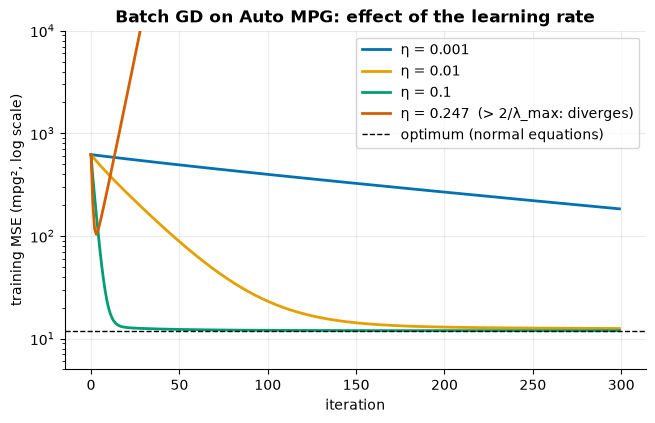

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for (lr, (_, losses)), color in zip(runs.items(), PALETTE):
    label = f"η = {lr}" + ("  (> 2/λ_max: diverges)" if lr > lr_crit else "")
    ax.plot(losses, color=color, lw=2, label=label)
ax.axhline(np.mean((Xb_tr @ theta_ne - y_tr) ** 2), color="black", ls="--", lw=1,
           label="optimum (normal equations)")
ax.set_yscale("log")
ax.set_ylim(5, 1e4)
ax.set_xlabel("iteration")
ax.set_ylabel("training MSE (mpg², log scale)")
ax.set_title("Batch GD on Auto MPG: effect of the learning rate")
ax.legend(loc="upper right", frameon=True)
savefig("gd_learning_rates")
plt.show()

- $\eta=0.001$: stable but painfully slow — still far from the optimum after 300 steps.
- $\eta=0.01$ and $0.1$: converge; larger is faster *as long as it stays below* $2/\lambda_{\max}$.
- Just 5 % above the critical value, the loss explodes exponentially.

### Stochastic and mini-batch gradient descent

Batch GD touches all $n$ rows per step. **Stochastic GD** (SGD) estimates the gradient from a single random
example; **mini-batch GD** from a small batch $B$:

$$\boldsymbol\theta \leftarrow \boldsymbol\theta - \eta_t\,\frac{2}{|B|}X_B^\top(X_B\boldsymbol\theta-\mathbf y_B).$$

The estimates are noisy but unbiased, so many cheap steps beat a few expensive ones on large data. The noise
means SGD never settles exactly unless the learning rate **decays**; we use $\eta_t = \eta_0/(1+t/t_0)$.
We visualise the parameter paths on the 1-feature synthetic problem from section 1.

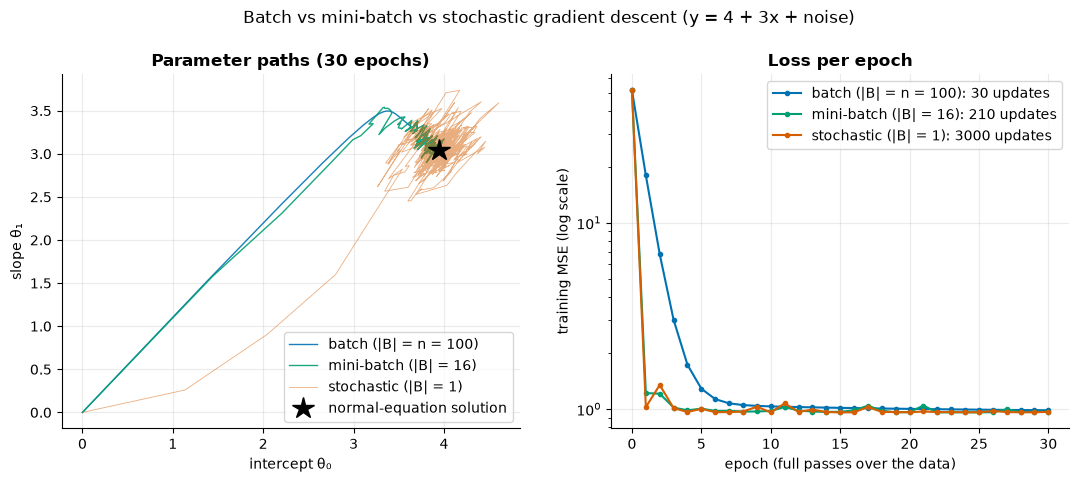

In [7]:
def minibatch_gd(X, y, batch_size, eta0=0.1, t0=200, n_epochs=30, seed=RANDOM_STATE):
    r = np.random.default_rng(seed)
    theta = np.zeros(X.shape[1])
    path, epoch_loss, t = [theta.copy()], [np.mean((X @ theta - y) ** 2)], 0
    for _ in range(n_epochs):
        idx = r.permutation(len(y))
        for start in range(0, len(y), batch_size):
            b = idx[start:start + batch_size]
            grad = 2 / len(b) * X[b].T @ (X[b] @ theta - y[b])
            theta -= eta0 / (1 + t / t0) * grad
            t += 1
            path.append(theta.copy())
        epoch_loss.append(np.mean((X @ theta - y) ** 2))
    return theta, np.array(path), np.array(epoch_loss)


configs = {"batch (|B| = n = 100)": 100, "mini-batch (|B| = 16)": 16, "stochastic (|B| = 1)": 1}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for (name, bs), color in zip(configs.items(), [PALETTE[0], PALETTE[2], PALETTE[3]]):
    theta, path, epoch_loss = minibatch_gd(Xb, y, bs)
    axes[0].plot(path[:, 0], path[:, 1], "-", color=color, lw=1 if bs > 1 else 0.6,
                 alpha=0.9 if bs > 1 else 0.5, label=name)
    axes[1].plot(epoch_loss, "o-", ms=3, color=color, label=f"{name}: {len(path) - 1} updates")
axes[0].plot(*theta_lstsq, "*", color="black", ms=16, zorder=5, label="normal-equation solution")
axes[0].set_xlabel("intercept θ₀")
axes[0].set_ylabel("slope θ₁")
axes[0].set_title("Parameter paths (30 epochs)")
axes[0].legend(loc="lower right", frameon=True)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch (full passes over the data)")
axes[1].set_ylabel("training MSE (log scale)")
axes[1].set_title("Loss per epoch")
axes[1].legend(frameon=True)
fig.suptitle("Batch vs mini-batch vs stochastic gradient descent (y = 4 + 3x + noise)", y=1.02)
savefig("gd_variants")
plt.show()

SGD makes 100 updates per epoch, so it gets close to the optimum after the first pass, then jitters around
it; batch GD makes one smooth update per epoch and needs many epochs. Mini-batches are the practical
compromise (and vectorise well on hardware).

**Verify against sklearn.** `SGDRegressor` implements the same idea (single-sample updates with a decaying
learning rate). On standardised Auto MPG, our mini-batch GD, `SGDRegressor` and the exact solution agree to
within the SGD noise:

In [8]:
theta_mb, _, _ = minibatch_gd(Xb_tr, y_tr, batch_size=16, eta0=0.05, t0=500, n_epochs=200)
sgd = SGDRegressor(penalty=None, learning_rate="adaptive", eta0=0.01, max_iter=10_000, tol=1e-5,
                   random_state=RANDOM_STATE).fit(X_tr, y_tr)
compare = pd.DataFrame({
    "normal equations": theta_ne,
    "our mini-batch GD": theta_mb,
    "sklearn SGDRegressor": np.r_[sgd.intercept_, sgd.coef_],
}, index=["intercept"] + features)
compare

,normal equations,our mini-batch GD,sklearn SGDRegressor
intercept,23.5994,23.5996,23.6051
cylinders,-0.1972,-0.1911,-0.1653
displacement,0.1050,0.1182,0.0031
horsepower,-0.0870,-0.0868,-0.1392
weight,-5.5099,-5.4951,-5.4052
acceleration,0.1737,0.1809,0.1387
model_year,2.7568,2.7587,2.7541


In [9]:
for name, col in compare.items():
    pred = Xb_te @ col.to_numpy()
    print(f"{name:22s} test RMSE = {root_mean_squared_error(y_te, pred):.4f} mpg")

normal equations       test RMSE = 3.2407 mpg
our mini-batch GD      test RMSE = 3.2327 mpg
sklearn SGDRegressor   test RMSE = 3.2474 mpg


Coefficients on the collinear engine features can differ noticeably between methods (the loss is very flat in
those directions), yet the test RMSE is essentially identical — the same lesson as in section 1.

## 4 · Regression metrics and residual analysis

| Metric | Formula | Units | Notes |
|---|---|---|---|
| MSE | $\frac1n\sum(y_i-\hat y_i)^2$ | target² | what OLS minimises; punishes large errors |
| RMSE | $\sqrt{\text{MSE}}$ | target | "typical" error size |
| MAE | $\frac1n\sum\lvert y_i-\hat y_i\rvert$ | target | robust to outliers; median-optimal |
| R² | $1-\dfrac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$ | none | fraction of variance explained; 0 = predict the mean, can be < 0 on test data |

In [10]:
def regression_metrics(y_true, y_pred):
    err = y_true - y_pred
    mse = np.mean(err**2)
    return {"MSE": mse, "RMSE": np.sqrt(mse), "MAE": np.mean(np.abs(err)),
            "R²": 1 - np.sum(err**2) / np.sum((y_true - y_true.mean()) ** 2)}


y_pred = ols.predict(X_te)
ours = regression_metrics(y_te, y_pred)
theirs = {"MSE": mean_squared_error(y_te, y_pred), "RMSE": root_mean_squared_error(y_te, y_pred),
          "MAE": mean_absolute_error(y_te, y_pred), "R²": r2_score(y_te, y_pred)}
pd.DataFrame({"from scratch": ours, "sklearn": theirs})

,from scratch,sklearn
MSE,10.5024,10.5024
RMSE,3.2407,3.2407
MAE,2.5039,2.5039
R²,0.7942,0.7942


A single number hides *how* the model is wrong. **Residuals** $e_i = y_i-\hat y_i$ should look like
structureless noise: centred on zero, constant spread, no pattern against the fitted values.

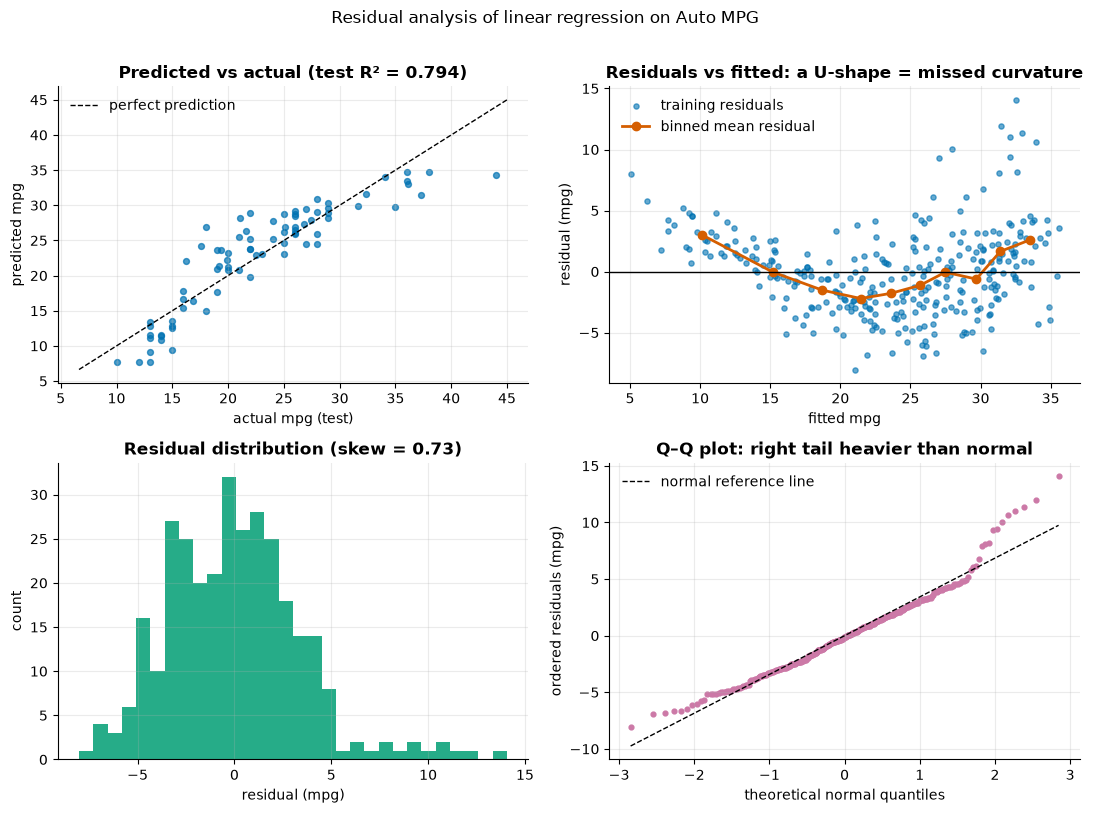

In [11]:
res_tr = y_tr - ols.predict(X_tr)
fitted_tr = ols.predict(X_tr)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes[0, 0]
ax.scatter(y_te, y_pred, s=18, alpha=0.7, color=PALETTE[0])
lims = [min(y_te.min(), y_pred.min()) - 1, max(y_te.max(), y_pred.max()) + 1]
ax.plot(lims, lims, "k--", lw=1, label="perfect prediction")
ax.set_xlabel("actual mpg (test)")
ax.set_ylabel("predicted mpg")
ax.set_title(f"Predicted vs actual (test R² = {r2_score(y_te, y_pred):.3f})")
ax.legend()

ax = axes[0, 1]
ax.scatter(fitted_tr, res_tr, s=14, alpha=0.6, color=PALETTE[0], label="training residuals")
order = np.argsort(fitted_tr)
bins = np.array_split(order, 10)
ax.plot([fitted_tr[b].mean() for b in bins], [res_tr[b].mean() for b in bins], "o-",
        color=PALETTE[3], lw=2, label="binned mean residual")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("fitted mpg")
ax.set_ylabel("residual (mpg)")
ax.set_title("Residuals vs fitted: a U-shape = missed curvature")
ax.legend()

ax = axes[1, 0]
ax.hist(res_tr, bins=30, color=PALETTE[2], alpha=0.85)
ax.set_xlabel("residual (mpg)")
ax.set_ylabel("count")
ax.set_title(f"Residual distribution (skew = {stats.skew(res_tr):.2f})")

ax = axes[1, 1]
(osm, osr), (slope, intercept, _) = stats.probplot(res_tr, dist="norm")
ax.scatter(osm, osr, s=12, color=PALETTE[4])
ax.plot(osm, slope * osm + intercept, "k--", lw=1, label="normal reference line")
ax.set_xlabel("theoretical normal quantiles")
ax.set_ylabel("ordered residuals (mpg)")
ax.set_title("Q–Q plot: right tail heavier than normal")
ax.legend()
fig.suptitle("Residual analysis of linear regression on Auto MPG", y=1.01)
fig.tight_layout()
savefig("residual_analysis")
plt.show()

The residuals-vs-fitted plot is U-shaped: the model under-predicts at both ends and over-predicts in the
middle, and the spread grows with the fitted value. The relationship between weight/horsepower and mpg is
curved (roughly mpg ∝ 1/weight). Two classic fixes are to model $\log(\text{mpg})$ or to add polynomial
terms:

In [12]:
def fit_eval(Xtr, Xte, ytr, log_target=False):
    m = LinearRegression().fit(Xtr, np.log(ytr) if log_target else ytr)
    pred = m.predict(Xte)
    return root_mean_squared_error(y_te, np.exp(pred) if log_target else pred)


poly2 = make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler()).fit(X_tr)
print(f"linear, raw target      : test RMSE = {fit_eval(X_tr, X_te, y_tr):.3f} mpg")
print(f"linear, log(mpg) target : test RMSE = {fit_eval(X_tr, X_te, y_tr, log_target=True):.3f} mpg")
print(f"degree-2 features       : test RMSE = "
      f"{fit_eval(poly2.transform(X_tr), poly2.transform(X_te), y_tr):.3f} mpg")

linear, raw target      : test RMSE = 3.241 mpg
linear, log(mpg) target : test RMSE = 2.653 mpg
degree-2 features       : test RMSE = 2.724 mpg


## 5 · Regularisation: Ridge, Lasso, Elastic Net

When features are many or collinear, OLS coefficients have high variance. Regularisation adds a penalty on
coefficient size (never on the intercept):

| Model | Objective (sklearn's scaling) | Effect |
|---|---|---|
| Ridge | $\lVert\mathbf y - X\mathbf w\rVert^2 + \alpha\lVert\mathbf w\rVert_2^2$ | shrinks all coefficients smoothly |
| Lasso | $\frac1{2n}\lVert\mathbf y - X\mathbf w\rVert^2 + \alpha\lVert\mathbf w\rVert_1$ | sets some coefficients **exactly** to 0 (feature selection) |
| Elastic Net | $\frac1{2n}\lVert\cdot\rVert^2 + \alpha\rho\lVert\mathbf w\rVert_1 + \frac{\alpha(1-\rho)}2\lVert\mathbf w\rVert_2^2$ | mix; keeps groups of correlated features together |

### Ridge from scratch

Centre $X$ and $\mathbf y$ (so the intercept is not penalised), then the Ridge gradient
$-2X^\top(\mathbf y - X\mathbf w) + 2\alpha\mathbf w = 0$ gives

$$\hat{\mathbf w}_{\text{ridge}} = (X^\top X + \alpha I)^{-1}X^\top\mathbf y,\qquad
  \hat w_0 = \bar y - \bar{\mathbf x}^\top\hat{\mathbf w}.$$

Adding $\alpha I$ lifts every eigenvalue of $X^\top X$ by $\alpha$, so the system is always well conditioned —
ridge is the cure for the collinearity problem of section 1.

We use the **diabetes** dataset (442 patients, 10 baseline measurements, target = disease progression one
year later). We load the *unscaled* version and standardise ourselves.

In [13]:
diab = load_diabetes(as_frame=True, scaled=False)
Xd, yd = diab.data, diab.target
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.25, random_state=RANDOM_STATE)
sc_d = StandardScaler().fit(Xd_tr)
Zd_tr, Zd_te = sc_d.transform(Xd_tr), sc_d.transform(Xd_te)


def ridge_closed_form(X, y, alpha):
    x_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - x_mean, y - y_mean
    w = np.linalg.solve(Xc.T @ Xc + alpha * np.eye(X.shape[1]), Xc.T @ yc)
    return y_mean - x_mean @ w, w


for alpha in [0.1, 10, 1000]:
    b, w = ridge_closed_form(Zd_tr, yd_tr.to_numpy(), alpha)
    r = Ridge(alpha=alpha).fit(Zd_tr, yd_tr)
    print(f"α = {alpha:>6}: matches sklearn Ridge → {np.allclose(w, r.coef_) and np.isclose(b, r.intercept_)}"
          f"   ‖w‖ = {np.linalg.norm(w):7.2f}")

α =    0.1: matches sklearn Ridge → True   ‖w‖ =   69.02
α =     10: matches sklearn Ridge → True   ‖w‖ =   42.71
α =   1000: matches sklearn Ridge → True   ‖w‖ =   15.16


### Coefficient paths

As $\alpha$ grows, Ridge shrinks every coefficient smoothly toward 0; Lasso drives them to **exactly** 0
one at a time — the order in which features leave is a crude importance ranking.

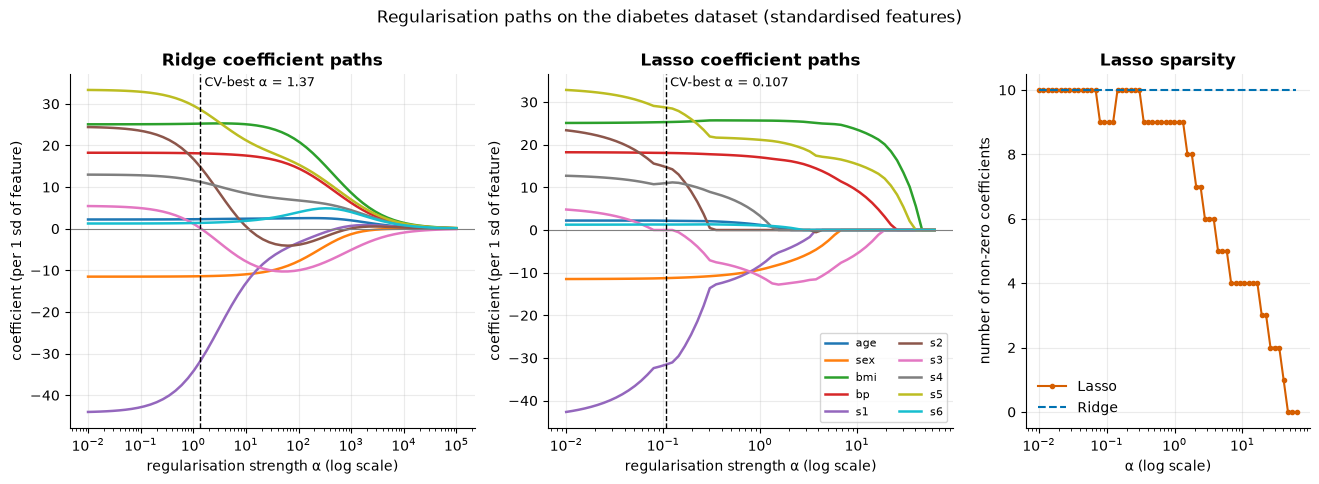

In [14]:
ridge_alphas = np.logspace(-2, 5, 60)
lasso_alphas = np.logspace(-2, 1.8, 60)
ridge_coefs = np.array([Ridge(alpha=a).fit(Zd_tr, yd_tr).coef_ for a in ridge_alphas])
lasso_coefs = np.array([Lasso(alpha=a, max_iter=50_000).fit(Zd_tr, yd_tr).coef_ for a in lasso_alphas])

ridge_cv = RidgeCV(alphas=ridge_alphas).fit(Zd_tr, yd_tr)
lasso_cv = LassoCV(alphas=lasso_alphas, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                   max_iter=50_000).fit(Zd_tr, yd_tr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1, 1, 0.7]})
colors = plt.cm.tab10(np.arange(10))
for ax, alphas, coefs, name, best in [(axes[0], ridge_alphas, ridge_coefs, "Ridge", ridge_cv.alpha_),
                                      (axes[1], lasso_alphas, lasso_coefs, "Lasso", lasso_cv.alpha_)]:
    for j, feat in enumerate(Xd.columns):
        ax.plot(alphas, coefs[:, j], color=colors[j], lw=1.8, label=feat)
    ax.axvline(best, color="black", ls="--", lw=1)
    ax.text(best, ax.get_ylim()[1] * 0.92, f" CV-best α = {best:.3g}", fontsize=9)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("regularisation strength α (log scale)")
    ax.set_ylabel("coefficient (per 1 sd of feature)")
    ax.set_title(f"{name} coefficient paths")
axes[1].legend(ncol=2, fontsize=8, loc="lower right", frameon=True)
axes[2].plot(lasso_alphas, (np.abs(lasso_coefs) > 0).sum(axis=1), "o-", ms=3, color=PALETTE[3], label="Lasso")
axes[2].plot(ridge_alphas[ridge_alphas <= lasso_alphas.max()],
             (np.abs(ridge_coefs[ridge_alphas <= lasso_alphas.max()]) > 0).sum(axis=1), "--",
             color=PALETTE[0], label="Ridge")
axes[2].set_xscale("log")
axes[2].set_xlabel("α (log scale)")
axes[2].set_ylabel("number of non-zero coefficients")
axes[2].set_title("Lasso sparsity")
axes[2].legend()
fig.suptitle("Regularisation paths on the diabetes dataset (standardised features)", y=1.02)
savefig("ridge_lasso_paths")
plt.show()

In [15]:
enet = ElasticNet(alpha=lasso_cv.alpha_, l1_ratio=0.5, max_iter=50_000).fit(Zd_tr, yd_tr)
ols_d = LinearRegression().fit(Zd_tr, yd_tr)
summary = pd.DataFrame({
    "OLS": ols_d.coef_, f"Ridge α={ridge_cv.alpha_:.3g}": ridge_cv.coef_,
    f"Lasso α={lasso_cv.alpha_:.3g}": lasso_cv.coef_, "ElasticNet (ρ=0.5)": enet.coef_,
}, index=Xd.columns)
summary.loc["test R²"] = [m.score(Zd_te, yd_te) for m in [ols_d, ridge_cv, lasso_cv, enet]]
summary.loc["non-zero coefs"] = [(np.abs(m.coef_) > 1e-10).sum() for m in [ols_d, ridge_cv, lasso_cv, enet]]
summary.round(3)

,OLS,Ridge α=1.37,Lasso α=0.107,ElasticNet (ρ=0.5)
age,2.215,2.289,2.176,2.372
sex,-11.514,-11.415,-11.280,-10.496
bmi,25.077,25.243,25.305,24.702
bp,18.249,18.095,18.065,17.169
s1,-44.145,-31.745,-31.554,-9.160
s2,24.514,14.822,14.750,-1.975
s3,5.498,0.107,-0.000,-9.369
s4,13.007,11.254,10.999,7.703
s5,33.380,28.614,28.714,19.587
s6,1.248,1.399,1.284,2.160


On this small, not-very-high-dimensional problem the regularised models score about the same as OLS on the
test set, but Lasso gets there with fewer features. Note how OLS gives large opposite-sign coefficients to
`s1` and `s2` (total and LDL cholesterol, which are strongly correlated) — regularisation tames exactly that.

### Why scaling matters for penalised models

The penalty $\alpha\sum_j w_j^2$ charges every coefficient the same price. But a coefficient's size depends on
its feature's units: weight in lb gets a *tiny* coefficient (mpg per lb) that is almost free to keep, while
the same information in 1000-lb units needs a coefficient 1000× larger, which the penalty punishes hard.
So on raw features, **Ridge's predictions depend on your choice of units**. OLS doesn't care, and neither does
Ridge on standardised features.

In [16]:
X_te_1000 = X_te_df.assign(weight=X_te_df["weight"] / 1000)
X_tr_1000 = X_tr_df.assign(weight=X_tr_df["weight"] / 1000)
rows = []
for model_name, make in [("OLS", LinearRegression), ("Ridge α=100, raw", lambda: Ridge(alpha=100)),
                         ("Ridge α=100, standardised", lambda: make_pipeline(StandardScaler(), Ridge(alpha=100)))]:
    row = {"model": model_name}
    for unit, Xa, Xb_ in [("lb", X_tr_df, X_te_df), ("1000 lb", X_tr_1000, X_te_1000)]:
        row[f"test RMSE, weight in {unit}"] = root_mean_squared_error(y_te, make().fit(Xa, y_tr).predict(Xb_))
    rows.append(row)
pd.DataFrame(rows).set_index("model").round(3)

,"test RMSE, weight in lb","test RMSE, weight in 1000 lb"
model,,
OLS,3.241,3.241
"Ridge α=100, raw",3.247,3.612
"Ridge α=100, standardised",3.373,3.373


Measuring weight in thousands of pounds should not change anything real, yet raw-feature Ridge gets a
noticeably worse model, because the now-large weight coefficient is shrunk hard. After standardising, the
unit choice is irrelevant. (That the standardised model is slightly worse here just means α = 100 is too
strong for it — tune α by cross-validation *after* scaling.) **Always scale before Ridge/Lasso** (inside a
pipeline).

## 6 · Polynomial regression: under- and over-fitting

We fit polynomials of increasing degree to 20 noisy samples of $f(x)=\sin(2\pi x)$, $\sigma=0.3$ — the
classic example from Bishop's *PRML*.

One numerical detail: on $[0,1]$ the columns $x^9, x^{10},\dots,x^{15}$ are almost identical (conditioning
again!), and `lstsq` silently drops the near-zero singular directions, which acts like hidden regularisation.
Mapping $x$ to $[-1,1]$ first makes the powers far less collinear, so high degrees really get to overfit.

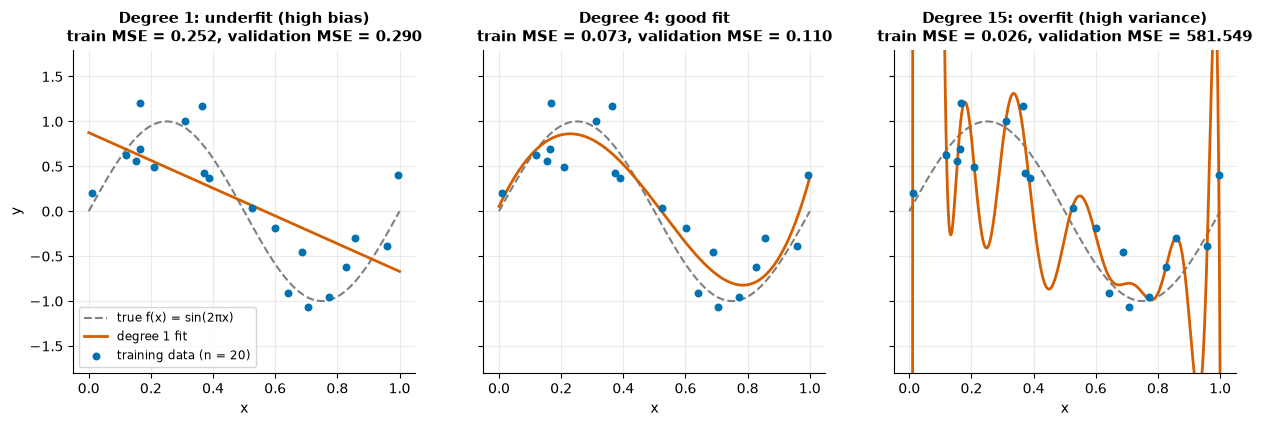

In [17]:
SIGMA = 0.3


def f_true(x):
    return np.sin(2 * np.pi * x)


def make_sine(n, r):
    x = r.uniform(0, 1, n)
    return x, f_true(x) + r.normal(0, SIGMA, n)


def to_unit_interval(x):
    return 2 * x - 1  # [0, 1] -> [-1, 1]


def poly_model(degree):
    return make_pipeline(FunctionTransformer(to_unit_interval), PolynomialFeatures(degree, include_bias=False),
                         StandardScaler(), LinearRegression())


x_s, y_s = make_sine(20, rng)
x_val, y_val = make_sine(2000, rng)  # large fresh sample ≈ the true test error
grid = np.linspace(0, 1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, degree, verdict in zip(axes, [1, 4, 15], ["underfit (high bias)", "good fit", "overfit (high variance)"]):
    m = poly_model(degree).fit(x_s[:, None], y_s)
    tr = mean_squared_error(y_s, m.predict(x_s[:, None]))
    va = mean_squared_error(y_val, m.predict(x_val[:, None]))
    ax.plot(grid, f_true(grid), color="grey", ls="--", lw=1.5, label="true f(x) = sin(2πx)")
    ax.plot(grid, m.predict(grid[:, None]), color=PALETTE[3], lw=2, label=f"degree {degree} fit")
    ax.scatter(x_s, y_s, s=22, color=PALETTE[0], zorder=3, label="training data (n = 20)")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"Degree {degree}: {verdict}\ntrain MSE = {tr:.3f}, validation MSE = {va:.3f}", fontsize=11)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="lower left", fontsize=8.5, frameon=True)
savefig("polynomial_fits")
plt.show()

### Validation curve: error vs model complexity

Training error can only go down as the degree rises (each model contains the previous one). Validation error
goes down, bottoms out, and shoots up. We show both a large fresh validation set (possible only because we
simulate) and the practical estimate, 5-fold cross-validation via `validation_curve`.

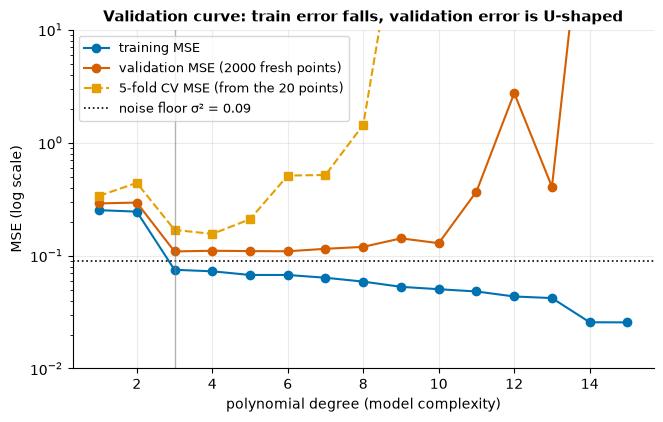

best degree by fresh validation: 3 | by 5-fold CV: 4


In [18]:
degrees = np.arange(1, 16)
train_mse, fresh_mse = [], []
for d in degrees:
    m = poly_model(d).fit(x_s[:, None], y_s)
    train_mse.append(mean_squared_error(y_s, m.predict(x_s[:, None])))
    fresh_mse.append(mean_squared_error(y_val, m.predict(x_val[:, None])))

_, cv_scores = validation_curve(poly_model(1), x_s[:, None], y_s,
                                param_name="polynomialfeatures__degree", param_range=degrees,
                                cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                                scoring="neg_mean_squared_error")
cv_mse = -cv_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(degrees, train_mse, "o-", color=PALETTE[0], label="training MSE")
ax.plot(degrees, fresh_mse, "o-", color=PALETTE[3], label="validation MSE (2000 fresh points)")
ax.plot(degrees, cv_mse, "s--", color=PALETTE[1], label="5-fold CV MSE (from the 20 points)")
ax.axhline(SIGMA**2, color="black", ls=":", lw=1.2, label=f"noise floor σ² = {SIGMA**2:.2f}")
best = degrees[int(np.argmin(fresh_mse))]
ax.axvline(best, color="grey", lw=1, alpha=0.6)
ax.set_yscale("log")
ax.set_ylim(0.01, 10)
ax.set_xlabel("polynomial degree (model complexity)")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Validation curve: train error falls, validation error is U-shaped", fontsize=11)
ax.legend(loc="upper left", fontsize=9, frameon=True)
savefig("validation_curve_degree")
plt.show()
print("best degree by fresh validation:", best, "| by 5-fold CV:", degrees[int(np.argmin(cv_mse))])

### Learning curves: error vs training-set size

A learning curve fixes the model and grows the training set. It answers *"would more data help?"*

- **High bias** (degree 1): train and validation errors converge quickly to a high plateau → more data won't
  help; use a richer model.
- **High variance** (degree 15): a big gap between train and validation error that narrows as $n$ grows →
  more data (or regularisation) helps.

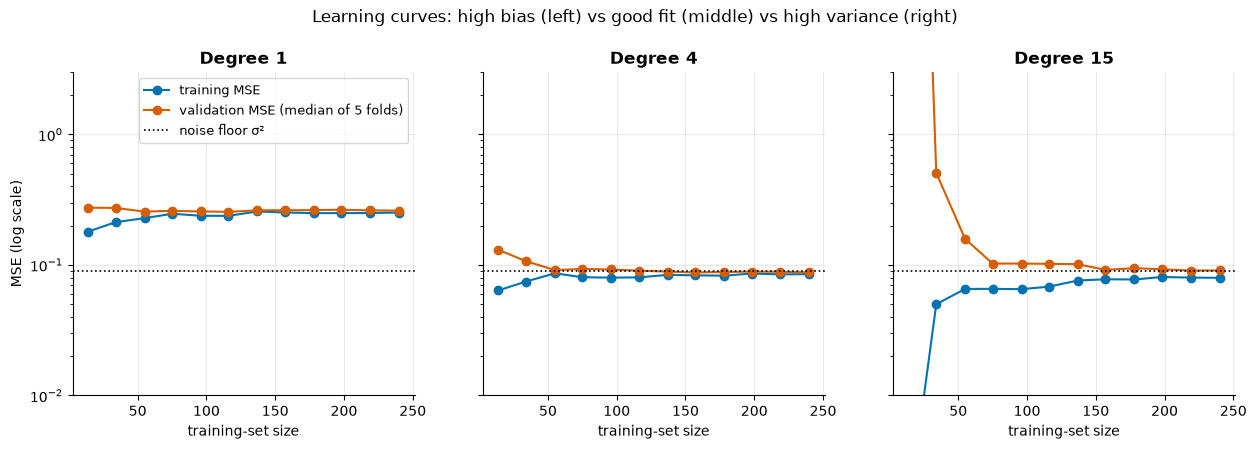

In [19]:
x_lc, y_lc = make_sine(300, rng)
sizes = np.linspace(0.06, 1.0, 12)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, degree in zip(axes, [1, 4, 15]):
    n_tr, tr_s, va_s = learning_curve(poly_model(degree), x_lc[:, None], y_lc, train_sizes=sizes,
                                      cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                                      scoring="neg_mean_squared_error")
    tr_m, va_m = -tr_s.mean(axis=1), -np.median(va_s, axis=1)
    ax.plot(n_tr, tr_m, "o-", color=PALETTE[0], label="training MSE")
    ax.plot(n_tr, va_m, "o-", color=PALETTE[3], label="validation MSE (median of 5 folds)")
    ax.axhline(SIGMA**2, color="black", ls=":", lw=1.2, label="noise floor σ²")
    ax.set_yscale("log")
    ax.set_ylim(0.01, 3)
    ax.set_xlabel("training-set size")
    ax.set_title(f"Degree {degree}")
axes[0].set_ylabel("MSE (log scale)")
axes[0].legend(loc="upper right", fontsize=9, frameon=True)
fig.suptitle("Learning curves: high bias (left) vs good fit (middle) vs high variance (right)", y=1.03)
savefig("learning_curves")
plt.show()

## 7 · The bias–variance decomposition

Imagine redrawing the training set $\mathcal D$ many times from the same distribution and refitting. At a
fixed input $x$ with $y = f(x)+\varepsilon$, $\operatorname{Var}(\varepsilon)=\sigma^2$, the expected squared
error of the fitted model $\hat f_{\mathcal D}$ decomposes exactly as

$$
\mathbb E_{\mathcal D,\varepsilon}\big[(y-\hat f_{\mathcal D}(x))^2\big]
= \underbrace{\big(f(x)-\mathbb E_{\mathcal D}[\hat f_{\mathcal D}(x)]\big)^2}_{\text{bias}^2}
+ \underbrace{\mathbb E_{\mathcal D}\big[(\hat f_{\mathcal D}(x)-\mathbb E_{\mathcal D}[\hat f_{\mathcal D}(x)])^2\big]}_{\text{variance}}
+ \underbrace{\sigma^2}_{\text{irreducible noise}} .
$$

(Expand the square around $\bar f(x)=\mathbb E_{\mathcal D}[\hat f_{\mathcal D}(x)]$; the cross terms vanish
because $\varepsilon$ is independent of $\mathcal D$ and has mean zero.)

Because we know $f$ and $\sigma$, we can **measure** each term: draw 300 training sets of 30 points, fit every
degree on each, and evaluate on a grid of $x$ values.

In [20]:
N_SETS, N_TRAIN = 300, 30
x_grid = np.linspace(0.02, 0.98, 100)
bv_degrees = np.arange(0, 10)
sim_rng = np.random.default_rng(RANDOM_STATE)
train_sets = [make_sine(N_TRAIN, sim_rng) for _ in range(N_SETS)]


def fit_predict(degree, x, y, x_new):
    if degree == 0:  # constant model = predict the training mean
        return np.full_like(x_new, y.mean())
    return poly_model(degree).fit(x[:, None], y).predict(x_new[:, None])


t0 = time.time()
preds = {d: np.array([fit_predict(d, xs, ys, x_grid) for xs, ys in train_sets]) for d in bv_degrees}
print(f"{N_SETS * len(bv_degrees)} fits in {time.time() - t0:.1f}s")

rows = []
for d, P in preds.items():  # P has shape (N_SETS, len(x_grid))
    mean_pred = P.mean(axis=0)
    bias2 = np.mean((mean_pred - f_true(x_grid)) ** 2)
    variance = np.mean(P.var(axis=0))
    # empirical expected test error with fresh noise, to check the identity
    y_new = f_true(x_grid) + sim_rng.normal(0, SIGMA, P.shape)
    test_mse = np.mean((y_new - P) ** 2)
    rows.append({"degree": d, "bias²": bias2, "variance": variance, "noise σ²": SIGMA**2,
                 "bias² + var + σ²": bias2 + variance + SIGMA**2, "measured test MSE": test_mse})
bv = pd.DataFrame(rows).set_index("degree")
bv.round(4)

3000 fits in 6.8s


,bias²,variance,noise σ²,bias² + var + σ²,measured test MSE
degree,,,,,
0,0.5155,0.0210,0.09,0.6265,0.6240
1,0.1763,0.0216,0.09,0.2880,0.2878
2,0.1749,0.0521,0.09,0.3170,0.3187
3,0.0035,0.0159,0.09,0.1094,0.1097
4,0.0034,0.0242,0.09,0.1175,0.1175
5,0.0001,0.0379,0.09,0.1280,0.1271
6,0.0003,0.0947,0.09,0.1849,0.1850
7,0.0002,0.6434,0.09,0.7336,0.7330
8,0.0040,1.3181,0.09,1.4121,1.4064


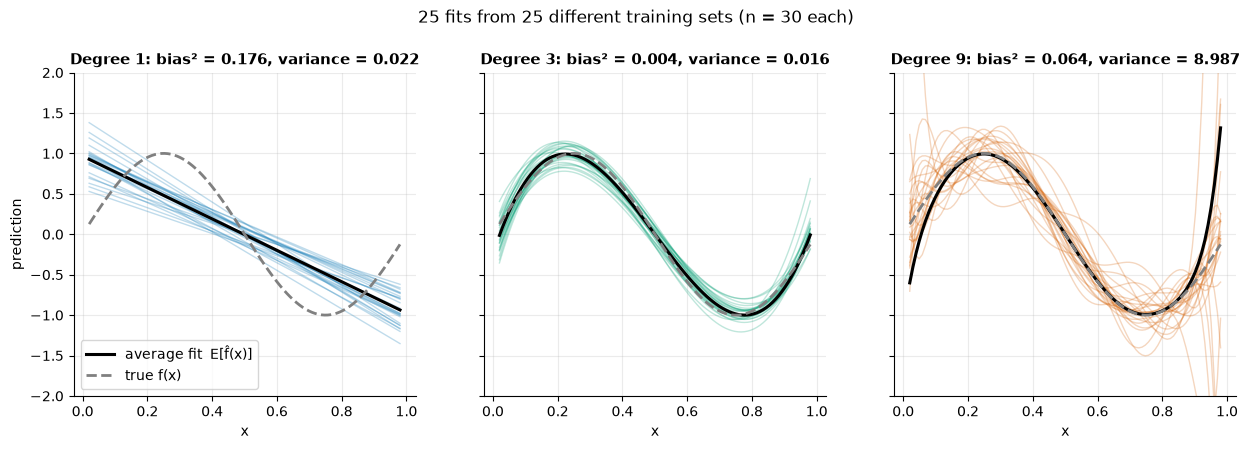

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, d, color in zip(axes, [1, 3, 9], [PALETTE[0], PALETTE[2], PALETTE[3]]):
    for P_row in preds[d][:25]:
        ax.plot(x_grid, P_row, color=color, alpha=0.25, lw=1)
    ax.plot(x_grid, preds[d].mean(axis=0), color="black", lw=2.2, label="average fit  E[f̂(x)]")
    ax.plot(x_grid, f_true(x_grid), color="grey", ls="--", lw=2, label="true f(x)")
    ax.set_ylim(-2, 2)
    ax.set_xlabel("x")
    ax.set_title(f"Degree {d}: bias² = {bv.loc[d, 'bias²']:.3f}, variance = {bv.loc[d, 'variance']:.3f}",
                 fontsize=11)
axes[0].set_ylabel("prediction")
axes[0].legend(loc="lower left", frameon=True)
fig.suptitle("25 fits from 25 different training sets (n = 30 each)", y=1.03)
savefig("bias_variance_fits")
plt.show()

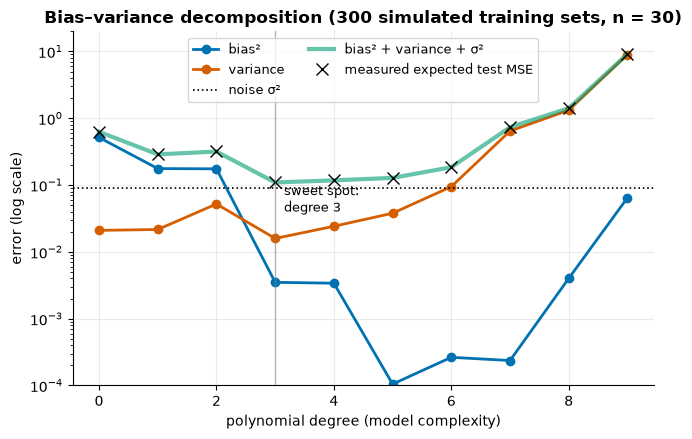

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(bv.index, bv["bias²"], "o-", color=PALETTE[0], lw=2, label="bias²")
ax.plot(bv.index, bv["variance"], "o-", color=PALETTE[3], lw=2, label="variance")
ax.axhline(SIGMA**2, color="black", ls=":", lw=1.2, label="noise σ²")
ax.plot(bv.index, bv["bias² + var + σ²"], "-", color=PALETTE[2], lw=3, alpha=0.6, label="bias² + variance + σ²")
ax.plot(bv.index, bv["measured test MSE"], "x", color="black", ms=8, label="measured expected test MSE")
best_d = bv["measured test MSE"].idxmin()
ax.axvline(best_d, color="grey", lw=1, alpha=0.6)
ax.text(best_d + 0.15, 4e-2, f"sweet spot:\ndegree {best_d}", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("polynomial degree (model complexity)")
ax.set_ylabel("error (log scale)")
ax.set_title("Bias–variance decomposition (300 simulated training sets, n = 30)")
ax.legend(loc="upper center", fontsize=9, frameon=True, ncol=2)
ax.set_ylim(1e-4, 20)
savefig("bias_variance_decomposition")
plt.show()

The crosses (test MSE measured directly with fresh noise) sit on the green curve (sum of the three terms) —
the identity holds numerically. Bias² falls as the model gets more flexible, variance rises, and the noise
floor $\sigma^2$ can never be beaten.

### When you have only one dataset: the bootstrap

In practice we can't redraw training sets from nature. **Bootstrap** resamples (drawing $n$ rows *with
replacement* from the one dataset we have) are a stand-in: the spread of predictions across bootstrap fits
estimates the variance term. (Bias can't be estimated this way — that needs the unknown $f$.)

In [23]:
x_one, y_one = train_sets[0]
boot_rows = []
for d in [1, 3, 5, 7]:
    P_boot = []
    for _ in range(200):
        idx = rng.integers(0, N_TRAIN, N_TRAIN)
        P_boot.append(fit_predict(d, x_one[idx], y_one[idx], x_grid))
    boot_rows.append({"degree": d, "bootstrap variance (1 dataset)": np.mean(np.var(P_boot, axis=0)),
                      "true variance (300 datasets)": bv.loc[d, "variance"]})
pd.DataFrame(boot_rows).set_index("degree").round(4)

,bootstrap variance (1 dataset),true variance (300 datasets)
degree,,
1,0.0144,0.0216
3,0.0122,0.0159
5,0.0205,0.0379
7,0.8593,0.6434


The bootstrap reproduces the key pattern — variance small for low degrees and exploding for high ones — but
not the exact values: all resamples reuse the same 30 $x$ positions (with duplicates), which is not the same as
drawing truly fresh datasets. This is the idea behind **bagging**
(chapter 07): average many bootstrap fits to cut variance.

## Key takeaways

- OLS has a closed form, $\hat{\boldsymbol\theta}=(X^\top X)^{-1}X^\top\mathbf y$, but compute it with
  `lstsq`/`pinv` (QR/SVD), never by inverting $X^\top X$ — that squares the condition number.
- Gradient descent converges iff $\eta<2/\lambda_{\max}(H)$; scale your features; SGD/mini-batch trade noisy
  steps for cheap ones and need a decaying learning rate.
- Report RMSE/MAE (in target units) *and* R²; always look at residual plots — they reveal curvature and
  heteroscedasticity that a single number hides.
- Ridge shrinks, Lasso selects; both require standardised features; choose $\alpha$ by cross-validation.
- Training error always falls with complexity; validation error is U-shaped. Learning curves tell you whether
  more data will help.
- Expected test error = bias² + variance + σ². Flexibility trades bias for variance; noise is irreducible.

## Exercises

1. **Ridge vs condition number.** For the near-collinear `X_col` from section 1, compute
   $\kappa(X^\top X + \alpha I)$ for $\alpha\in\{10^{-6},10^{-3},1\}$ and the resulting coefficients.
   *Hint: `np.linalg.cond` and the `ridge_closed_form` function (drop the bias column first).*
2. **Learning-rate finder.** Run `batch_gd` on the *unscaled* Auto MPG features. What is the critical learning
   rate now, and how many iterations would you need? *Hint: recompute `λ_max` of $\frac2nX^\top X$ with raw
   columns.*
3. **Huber loss.** Add three large outliers to the synthetic data of section 1 and compare
   `LinearRegression`, `HuberRegressor` and the MAE-optimal fit. *Hint: `sklearn.linear_model.HuberRegressor`.*
4. **Regularised polynomials.** Replace `LinearRegression` with `Ridge(alpha)` in `poly_model(15)` and plot
   the validation curve over $\alpha$ instead of degree. *Hint: `param_name="ridge__alpha"`.*
5. **Bias–variance vs n.** Re-run the simulation with $n=100$ training points. Which term changes, and where
   does the sweet spot move? *Hint: change `N_TRAIN`; variance should shrink roughly like $1/n$.*